In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator

In [2]:
path = r'C:\Users\artoe\Documents\DataAnalytics\projects\india weather\archive'

In [3]:
df = pd.read_pickle(os.path.join(path, 'daily_weather_updated_2.pkl'))

## Exploring Relationships between Variables

### Correlation between Variables

In [6]:
corr_sub = df[['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean','temp_diff_min', 'temp_diff_max', 'temp_diff_mean','precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant']] 

In [7]:
corr_sub.corr()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,temp_diff_min,temp_diff_max,temp_diff_mean,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
temperature_2m_max,1.000000,0.700101,0.913329,0.898065,0.591302,0.760364,0.248321,0.224780,0.242245,-0.171679,-0.171679,-0.113443,0.176743,0.159742,0.076199
temperature_2m_min,0.700101,1.000000,0.930197,0.870750,0.970569,0.965242,0.718513,0.693491,0.723726,0.177757,0.177757,0.411934,0.386666,0.372513,0.039722
temperature_2m_mean,0.913329,0.930197,1.000000,0.958250,0.857483,0.941353,0.537422,0.511051,0.537272,0.013122,0.013122,0.176611,0.311373,0.294562,0.061824
apparent_temperature_max,0.898065,0.870750,0.958250,1.000000,0.837818,0.949637,0.604548,0.630473,0.633783,-0.017396,-0.017396,0.165140,0.136111,0.117715,0.027193
apparent_temperature_min,0.591302,0.970569,0.857483,0.837818,1.000000,0.966697,0.864862,0.812532,0.859389,0.208929,0.208929,0.487210,0.301802,0.296489,0.020474
apparent_temperature_mean,0.760364,0.965242,0.941353,0.949637,0.966697,1.000000,0.779785,0.761903,0.790348,0.111761,0.111761,0.357050,0.237026,0.225353,0.024498
temp_diff_min,0.248321,0.718513,0.537422,0.604548,0.864862,0.779785,1.000000,0.901027,0.973325,0.232855,0.232855,0.548398,0.065599,0.079755,-0.023672
temp_diff_max,0.224780,0.693491,0.511051,0.630473,0.812532,0.761903,0.901027,1.000000,0.976510,0.264419,0.264419,0.566018,-0.010371,-0.021122,-0.074225
temp_diff_mean,0.242245,0.723726,0.537272,0.633783,0.859389,0.790348,0.973325,0.976510,1.000000,0.255529,0.255529,0.571798,0.027100,0.028446,-0.051019
precipitation_sum,-0.171679,0.177757,0.013122,-0.017396,0.208929,0.111761,0.232855,0.264419,0.255529,1.000000,1.000000,0.460591,0.182953,0.207712,0.008890


In [8]:
corr_sub.corr().to_clipboard()

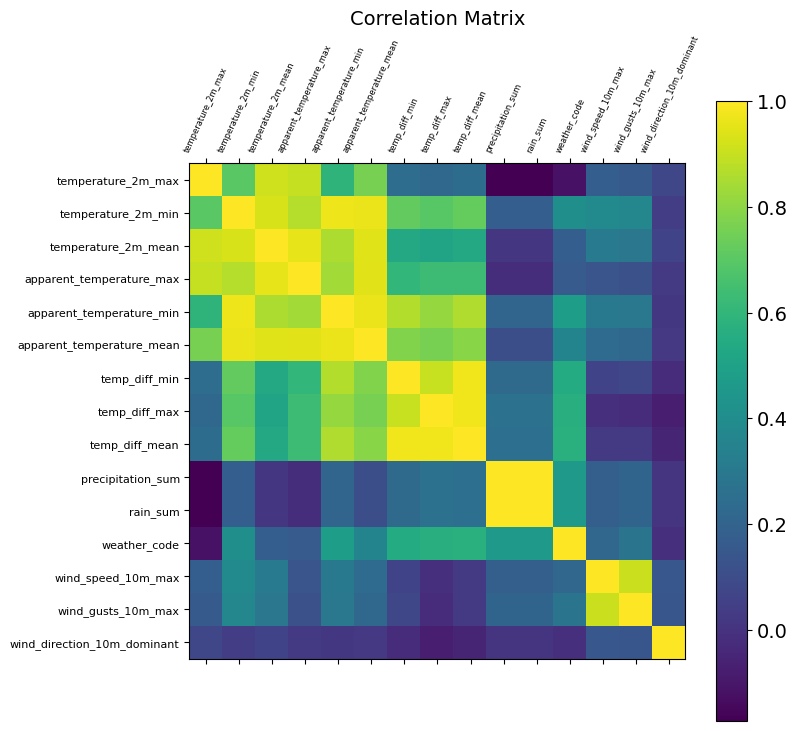

In [9]:
f = plt.figure(figsize=(8, 8))
plt.matshow(corr_sub.corr(), fignum=f.number)
plt.xticks(range(corr_sub.shape[1]), corr_sub.columns, fontsize=6, rotation=65.5)
plt.yticks(range(corr_sub.shape[1]), corr_sub.columns, fontsize=8)
cb = plt.colorbar() 
cb.ax.tick_params(labelsize=14) 
plt.title('Correlation Matrix', fontsize=14)
plt.show()

The numbers in this correlation matrix represent the strength of the relationship between each variable. A correlation coefficient of 1 indicates a perfectly matching relationship, a coefficient of 0 indicates no relationship at all. A negative value indicates an inverse relationship.

As noted before, weather codes with higher numbers indicate, in this data, increasing clouds and precipitation.

#### Observations:

Wind direction does not have any significant effect on other weather conditions nor on the weather code assigned.

Maximum temperature does not appear to have any correlation with the weather code (possibly due to all of the cities listed having a subtropical/tropical monsoon climate)

Precipitation and rain have the strongest correlation with weather code (again, due to higher numbers representing rainier conditions)

Precipitation and rain correlate perfectly (again, due to the warm climate of the cities contained, there is not likely to be other forms of precipitation such as snow, sleet, etc.)

## Frequency of Weather Codes across Cities

In [12]:
# understanding the weather code values
weathercode_dict = dict(zip(df['weather_code'], df['wmo_description']))

In [13]:
weathercode_dict

{0: 'Cloud development not observed or not observable',
 3: 'Clouds generally forming or developing',
 63: 'Rain, not freezing, continuous, moderate at time of observation',
 53: 'Drizzle, not freezing, continuous, moderate at time of observation',
 2: 'State of sky on the whole unchanged',
 1: 'Clouds generally dissolving or becoming less developed',
 51: 'Drizzle, not freezing, continuous, slight at time of observation',
 61: 'Rain, not freezing, continuous, slight at time of observation',
 55: 'Drizzle, not freezing, continuous, heavy (dense) at time of observation',
 65: 'Rain, not freezing, continuous, heavy at time of observation'}

<Axes: xlabel='weather_code', ylabel='Count'>

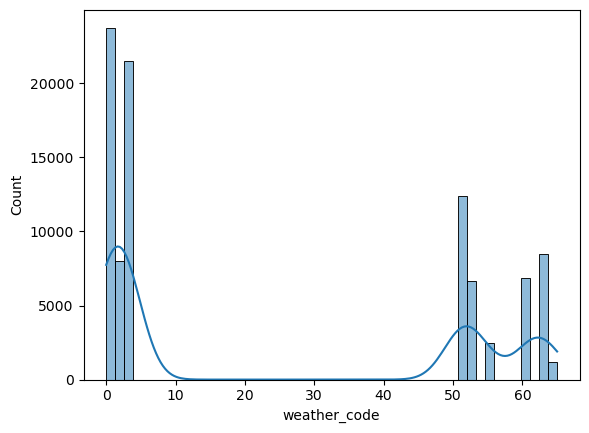

In [14]:
#show the distribution of weather codes across whole data set
sns.histplot(df['weather_code'], bins = 50, kde = True)

At least half of all records in this dataset show weather codes from 0 to 10, in this case, codes 0, 1, 2 and 3. This means that at least half the days recorded did not have any rain or precipitation.

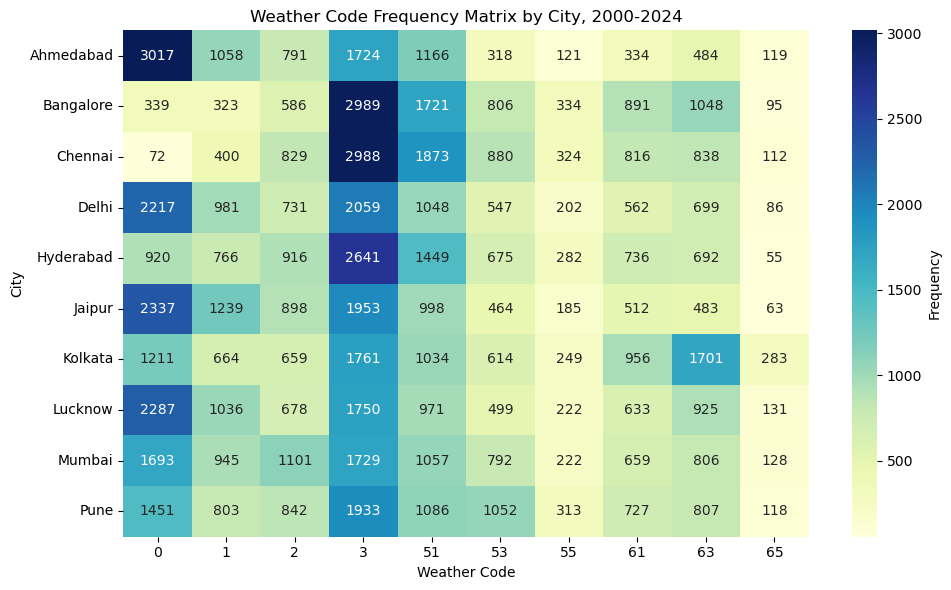

In [16]:
# Pivot data to get counts of each weather condition per city
pivot_df = df.groupby(['city', 'weather_code']).size().unstack(fill_value=0)

# Render a single consolidated grid heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Frequency'})
plt.title('Weather Code Frequency Matrix by City, 2000-2024')
plt.ylabel('City')
plt.xlabel('Weather Code')
plt.tight_layout()
plt.show()


### Observations

Ahmedabad had the highest frequency of clear days (weather code 0), Chennai had the lowest frequency. This was also the most commonly-observed weather code for Delhi, Jaipur and Lucknow.

Bangalore, Chennai and Hyderabad had the highest frequency of generally-cloudy days (weather code 3). This was also the most commonly-observed weather code for Mumbai, Kolkata and Pune. 

Chennai, Bangalore and Hyderabad had the highest frequency of days with light drizzle (weather code 51).

Weather codes 55 (heavy, continuous drizzle) and 65 (heavy, continuous rain) were the least common across all cities. Bangalore, Chennai and Pune showed the highest frequency of weather code 55, while Kolkata showed the highest frequency of weather code 65.

Kolkata also showed the highest frequency of weather code 63 (moderate rain) compared to other cities. 

### Weather Code Frequency for All Cities, Selected Years

In [19]:
#create a subset for each year
df_2000 =  df[df['year']==2000]
df_2012 =  df[df['year']==2012]
df_2024 =  df[df['year']==2024]

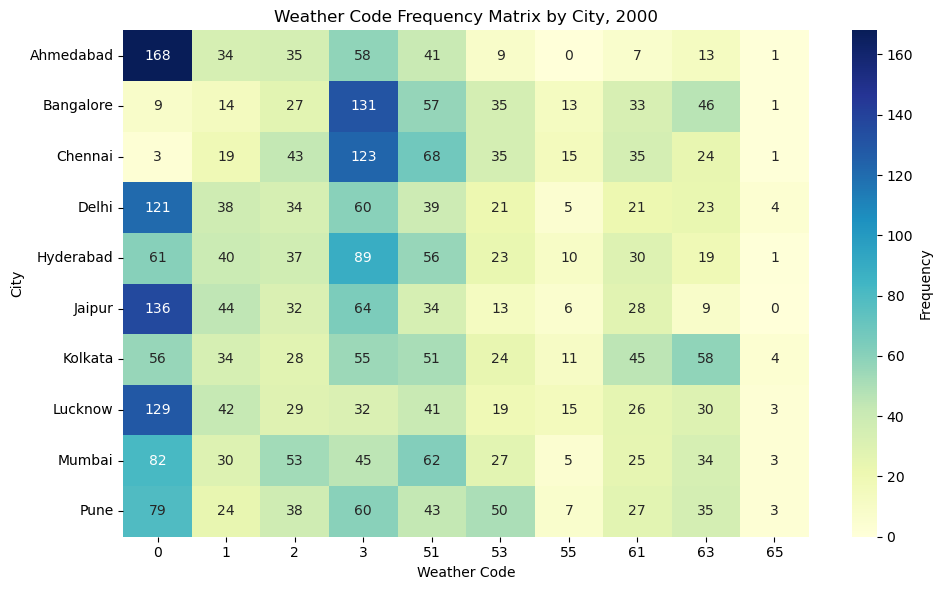

In [20]:
pivot_2000 = df_2000.groupby(['city', 'weather_code']).size().unstack(fill_value=0)

# Render a single consolidated grid heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_2000, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Frequency'})
plt.title('Weather Code Frequency Matrix by City, 2000')
plt.ylabel('City')
plt.xlabel('Weather Code')
plt.tight_layout()
plt.show()

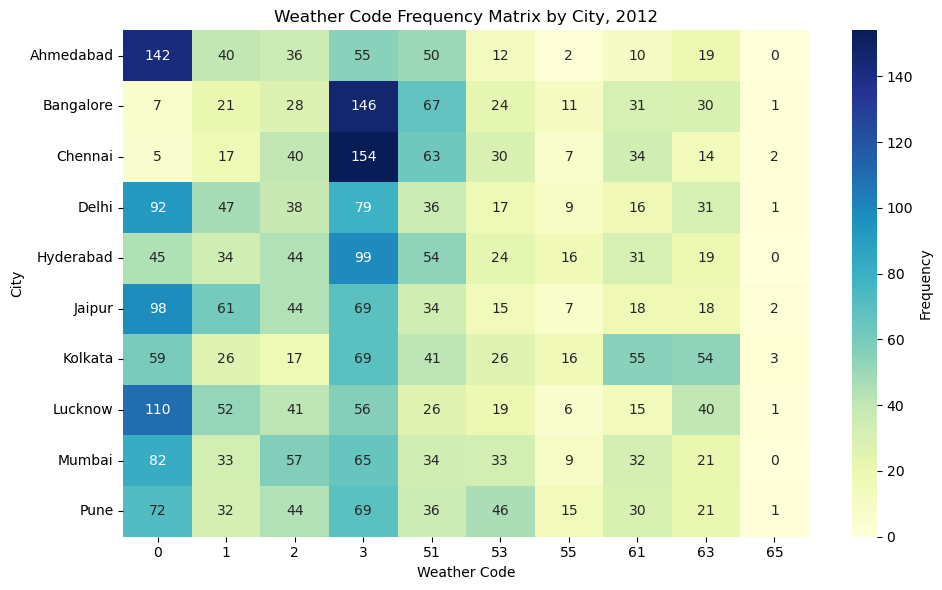

In [21]:
pivot_2012 = df_2012.groupby(['city', 'weather_code']).size().unstack(fill_value=0)

# Render a single consolidated grid heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_2012, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Frequency'})
plt.title('Weather Code Frequency Matrix by City, 2012')
plt.ylabel('City')
plt.xlabel('Weather Code')
plt.tight_layout()
plt.show()

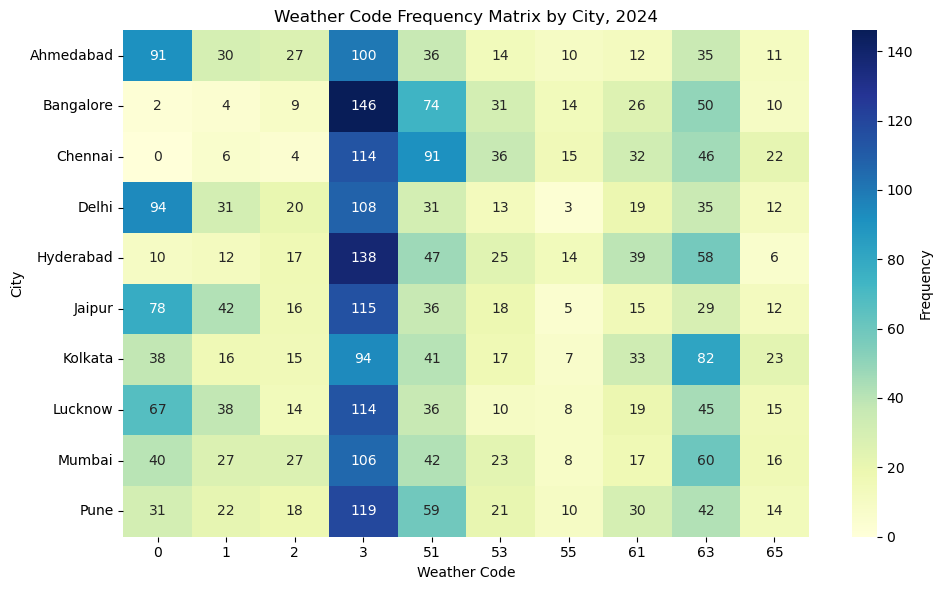

In [22]:
pivot_2024 = df_2024.groupby(['city', 'weather_code']).size().unstack(fill_value=0)

# Render a single consolidated grid heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_2024, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Frequency'})
plt.title('Weather Code Frequency Matrix by City, 2024')
plt.ylabel('City')
plt.xlabel('Weather Code')
plt.tight_layout()
plt.show()

### Observations

Ahmedabad's precipitation levels appear to have increased between 2000 and 2024, with fewer occurrences of weather code 0 (clear skies) and increasing numbers of days with cloudy and rainy conditions. 

Weather code 65 (heavy, continuous, non-freezing rain) appears to have increased in overal frequency betweeen 2012 and 2024, with all cities showing higher counts of this weather code in 2024. 

## Other Correlations

### Correlation between Wind and Rain

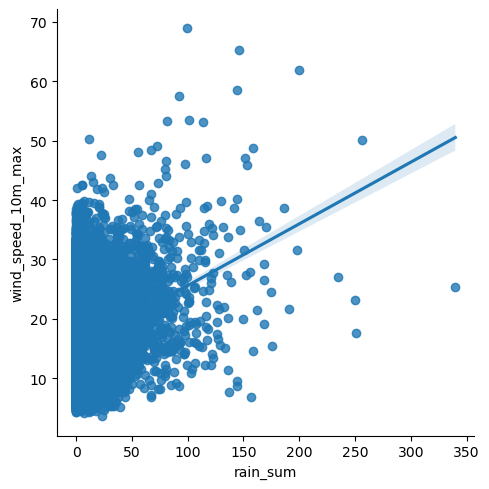

In [26]:
sns.lmplot(x = 'rain_sum', y = 'wind_speed_10m_max', data = df)

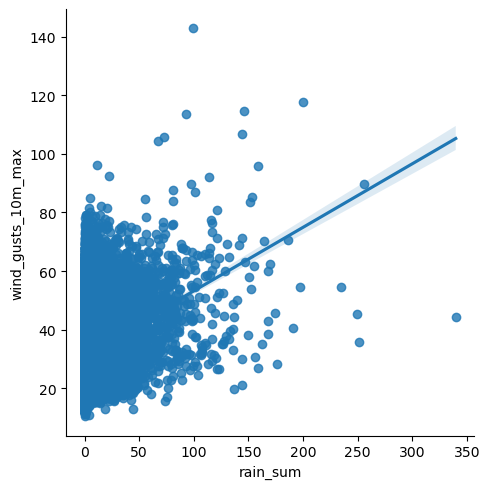

In [27]:
sns.lmplot(x = 'rain_sum', y = 'wind_gusts_10m_max', data = df)

### Correlation between Apparent Temperature and Rain

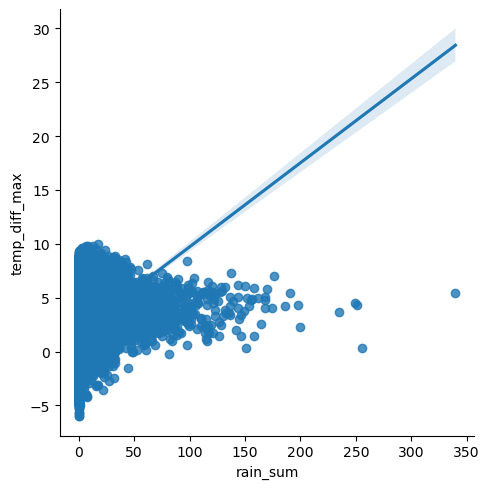

In [29]:
sns.lmplot(x = 'rain_sum', y = 'temp_diff_max', data = df)

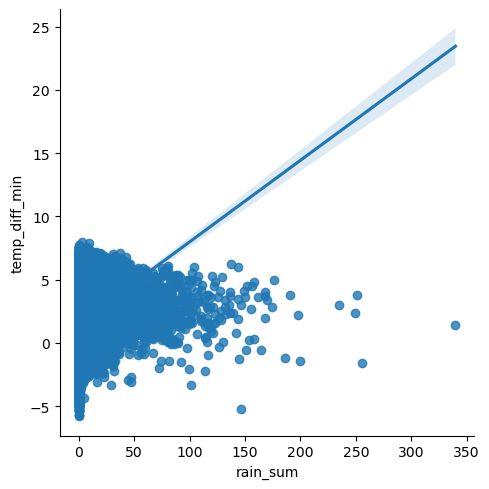

In [30]:
sns.lmplot(x = 'rain_sum', y = 'temp_diff_min', data = df)

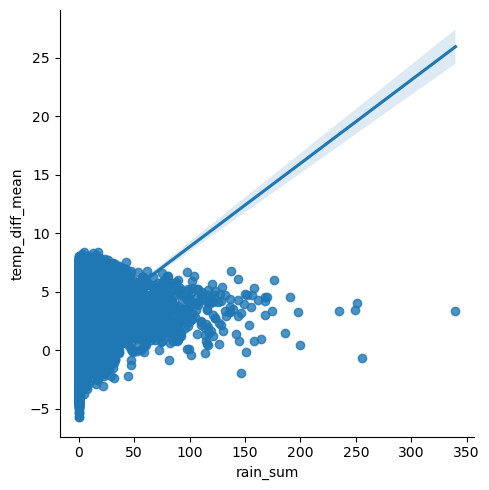

In [31]:
sns.lmplot(x = 'rain_sum', y = 'temp_diff_mean', data = df)

### Observations

There is a positive correlation between rain and the difference between apparent and actual temperature.

There is a weaker positive correlation between rain and wind speed, as well as rain and wind gusts.

Rain data is heavily skewed to the right, with a large number of records showing 0 rain.

Further data on humidity levels and cloud cover would also be helpful in determining the cause of higher and lower apparent temperatures.

### Correlation between Perceived Temperature and Max Wind Speed

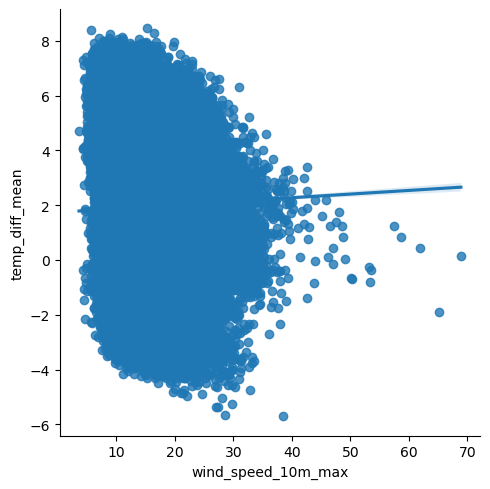

In [34]:
sns.lmplot(x = 'wind_speed_10m_max', y = 'temp_diff_mean', data = df)

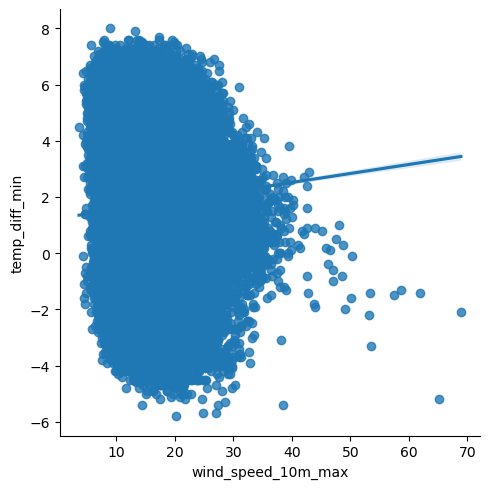

In [35]:
sns.lmplot(x = 'wind_speed_10m_max', y = 'temp_diff_min', data = df)

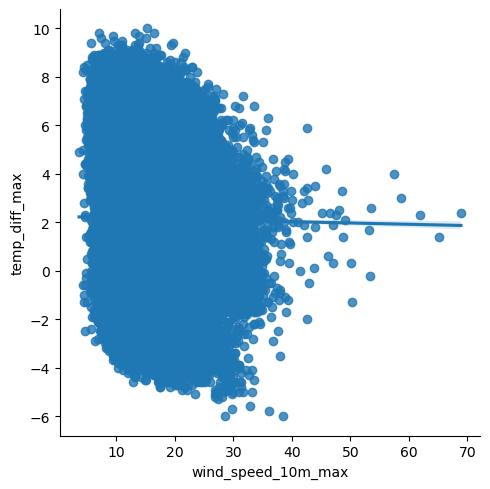

In [36]:
sns.lmplot(x = 'wind_speed_10m_max', y = 'temp_diff_max', data = df)

### Observations

All correlations between wind speed and its effect on apparent temperature are very weak. 

There is a noticeable positive correlation between wind speed and the difference between actual and apparent minimum temperatures. This indicates that higher wind speeds cause minimum temperatures to feel colder than they are.

There is a slight negative correlation between wind speed and the difference between actual and apparent maximum temperature. Again, this indicates the cooling effect of higher wind speeds.